In [25]:
# Open terminal in your project folder
!git init
!git add .
!git commit -m "Initial commit: dataset and project setup"

Reinitialized existing Git repository in C:/Users/User/OneDrive/4ftc2113  25001700/CW3/.git/
On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


# Mental Health Analysis
- Student ID: 25001700
- Module code:4FTC2113

# Importing necessary Libraries
- Imported necessary libraries such as pandas for data manipulation, numpy for numerical computing , matplotlib and seaborn for visualisaations.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('data.csv')
df.head()
df.describe()


,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,41.557600,5.572000,6.473000,3.505700,15.039900,10.56180,50.117700,77.312210
std,13.749581,2.887741,1.473944,2.282737,8.990839,6.32264,29.229278,14.061202
min,18.000000,1.000000,3.000000,0.000000,0.000000,0.00000,0.000000,42.800000
25%,30.000000,3.000000,5.500000,2.000000,7.000000,5.00000,25.000000,65.800000
50%,41.500000,6.000000,6.500000,4.000000,15.000000,11.00000,50.000000,77.600000
75%,53.000000,8.000000,7.500000,5.000000,23.000000,16.00000,76.000000,89.200000
max,65.000000,10.000000,10.000000,7.000000,30.000000,21.00000,100.000000,100.000000


# Data Preprocessing and cleaning
- As this dataset had no missing values and duplicates the preprocessing was done by one hot encoding, standard scalling and outlier capping.

In [28]:
print("Current columns:", df.columns.tolist())


Current columns: ['age', 'gender', 'employment_status', 'work_environment', 'mental_health_history', 'seeks_treatment', 'stress_level', 'sleep_hours', 'physical_activity_days', 'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score', 'mental_health_risk']


In [29]:
df.isnull().sum()

age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64

In [30]:
duplicates = df.duplicated().sum()
print(duplicates)

0


In [31]:
# In your code/report:
print("Data types:")
print(df.dtypes)

Data types:
age                         int64
gender                     object
employment_status          object
work_environment           object
mental_health_history      object
seeks_treatment            object
stress_level                int64
sleep_hours               float64
physical_activity_days      int64
depression_score            int64
anxiety_score               int64
social_support_score        int64
productivity_score        float64
mental_health_risk         object
dtype: object


In [32]:
print("Unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} values")

Unique values per column:
age: 48 values
gender: 4 values
employment_status: 4 values
work_environment: 3 values
mental_health_history: 2 values
seeks_treatment: 2 values
stress_level: 10 values
sleep_hours: 71 values
physical_activity_days: 8 values
depression_score: 31 values
anxiety_score: 22 values
social_support_score: 101 values
productivity_score: 546 values
mental_health_risk: 3 values


In [33]:
print("Current gender values:")
print(df['gender'].value_counts())

Current gender values:
gender
Male                 4557
Female               4457
Non-binary            520
Prefer not to say     466
Name: count, dtype: int64


In [34]:
print(df['work_environment'].value_counts())
print(df['employment_status'].value_counts())
print(df['mental_health_history'].value_counts())
print(df['seeks_treatment'].value_counts())
print(df['mental_health_risk'].value_counts())


work_environment
On-site    5044
Remote     3009
Hybrid     1947
Name: count, dtype: int64
employment_status
Employed         5868
Student          2043
Self-employed    1045
Unemployed       1044
Name: count, dtype: int64
mental_health_history
No     6969
Yes    3031
Name: count, dtype: int64
seeks_treatment
No     6012
Yes    3988
Name: count, dtype: int64
mental_health_risk
Medium    5892
High      2369
Low       1739
Name: count, dtype: int64


In [35]:
categorical_cols = ['gender', 'work_environment', 'employment_status', 
                    'mental_health_history', 'mental_health_risk']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
# Create mental health composite score
df['mental_health_composite'] = (
    df['depression_score'] + df['anxiety_score'] - df['social_support_score']
)

# Categorize stress levels
df['stress_category'] = pd.cut(
    df['stress_level'], 
    bins=[0, 3, 7, 10],
    labels=['Low', 'Medium', 'High']
)
# Calculate sleep efficiency ratio
df['sleep_activity_ratio'] = df['sleep_hours'] / (df['physical_activity_days'] + 1)

In [ ]:
# Identify outliers using IQR
Q1 = df[['stress_level', 'depression_score']].quantile(0.25)
Q3 = df[['stress_level', 'depression_score']].quantile(0.75)
IQR = Q3 - Q1

# Cap, remove, or keep with explanation
df['stress_level_capped'] = np.where(
    df['stress_level'] > (Q3['stress_level'] + 1.5 * IQR['stress_level']),
    Q3['stress_level'] + 1.5 * IQR['stress_level'],
    df['stress_level']
)

In [ ]:
# One-hot encode stress_category
df = pd.get_dummies(df, columns=['stress_category'], drop_first=True)

In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['seeks_treatment_encoded'] = le.fit_transform(df['seeks_treatment'])

In [40]:
X = df.drop(['seeks_treatment', 'seeks_treatment_encoded'], axis=1)
y = df['seeks_treatment_encoded']
print(f"Final feature shape: {X.shape}")
print(f"Target distribution: {y.value_counts(normalize=True)}")

Final feature shape: (10000, 24)
Target distribution: seeks_treatment_encoded
0    0.6012
1    0.3988
Name: proportion, dtype: float64


In [41]:
df.head()

,age,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,gender_Male,...,employment_status_Unemployed,mental_health_history_Yes,mental_health_risk_Low,mental_health_risk_Medium,mental_health_composite,sleep_activity_ratio,stress_level_capped,stress_category_Medium,stress_category_High,seeks_treatment_encoded
0,56,Yes,6,6.2,3,28,17,54,59.7,True,...,False,True,False,False,-9,1.550000,6.0,True,False,1
1,46,Yes,10,9.0,4,30,11,85,54.9,False,...,False,False,False,False,-44,1.800000,10.0,False,True,1
2,32,No,7,7.7,2,24,7,62,61.3,False,...,False,True,False,True,-31,2.566667,7.0,True,False,0
3,60,No,4,4.5,4,6,0,95,97.0,False,...,False,False,True,False,-89,0.900000,4.0,True,False,0
4,25,Yes,3,5.4,0,24,12,70,69.0,False,...,False,True,False,False,-34,5.400000,3.0,False,False,1


## Saving the preprocessed dataset

In [42]:
df.to_csv('data_preprocessed.csv', index=False)

# T- testing


In [ ]:
# T-test for Treatment Seekers vs Non-Seekers

from scipy import stats

# Compare means between groups
group_yes = df[df['seeks_treatment'] == 'Yes']
group_no = df[df['seeks_treatment'] == 'No']

print("=== T-TEST RESULTS: Treatment Seekers vs Non-Seekers ===\\n")

for col in ['depression_score', 'anxiety_score', 'stress_level', 'social_support_score']:
    t_stat, p_val = stats.ttest_ind(group_yes[col], group_no[col])
    print(f"{col}:")
    print(f"  Treatment Yes (n={len(group_yes)}): Mean = {group_yes[col].mean():.2f}")
    print(f"  Treatment No  (n={len(group_no)}): Mean = {group_no[col].mean():.2f}")
    print(f"  t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")
    print(f"  Interpretation: {'Significant difference' if p_val < 0.05 else 'No significant difference'}\\n")

=== T-TEST RESULTS: Treatment Seekers vs Non-Seekers ===\n
depression_score:
  Treatment Yes (n=3988): Mean = 15.07
  Treatment No  (n=6012): Mean = 15.02
  t-statistic = 0.247, p-value = 0.8047
  Interpretation: No significant difference\n
anxiety_score:
  Treatment Yes (n=3988): Mean = 10.65
  Treatment No  (n=6012): Mean = 10.51
  t-statistic = 1.090, p-value = 0.2756
  Interpretation: No significant difference\n
stress_level:
  Treatment Yes (n=3988): Mean = 5.54
  Treatment No  (n=6012): Mean = 5.59
  t-statistic = -0.878, p-value = 0.3800
  Interpretation: No significant difference\n
social_support_score:
  Treatment Yes (n=3988): Mean = 49.93
  Treatment No  (n=6012): Mean = 50.24
  t-statistic = -0.521, p-value = 0.6020
  Interpretation: No significant difference\n


In [44]:
!git add .
!git commit -m "Completed data preprocessing and exploratory analysis"

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


# Model


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


# Load dataset
data = pd.read_csv('data_preprocessed.csv')

# Final split
X = data.drop(columns=['seeks_treatment'])
y = data['seeks_treatment']

# Convert target variable from string to numeric 
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale numerical features only (not the one-hot encoded booleans)
numerical_cols = ['age', 'stress_level', 'sleep_hours', 'physical_activity_days',
                  'depression_score', 'anxiety_score', 'social_support_score',
                  'productivity_score', 'mental_health_composite', 'sleep_activity_ratio',
                  'stress_level_capped']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Target balance: {np.mean(y_train):.3f} positive ({np.sum(y_train)}/{len(y_train)})")

# Initialize and train the model with improved parameters
model = LogisticRegression(
    random_state=42, 
    max_iter=2000, 
    class_weight='balanced',
    solver='lbfgs',
    C=1.0,
    penalty='l2'
)
model.fit(X_train_scaled, y_train)

# Quick evaluation
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Full evaluation
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Treatment', 'Seeks Treatment']))

# Get coefficients
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})
feature_importance['Abs_Importance'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)
for idx, row in feature_importance.head(10).iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"{row['Feature']:30} → {direction} treatment seeking (coef: {row['Coefficient']:.4f})")


# Additional metrics and insights
print("\n" + "="*50)
print("ADDITIONAL INSIGHTS")
print("="*50)

# Calculate precision, recall, F1 for each class
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"Precision for 'No Treatment': {precision_0:.3f}")
print(f"Precision for 'Seeks Treatment': {precision_1:.3f}")
print(f"Recall for 'No Treatment': {recall_0:.3f}")
print(f"Recall for 'Seeks Treatment': {recall_1:.3f}")

# Predictions vs actual
print(f"\nTotal predictions: {len(y_pred)}")
print(f"Correct predictions: {np.sum(y_pred == y_test)}")
print(f"Incorrect predictions: {np.sum(y_pred != y_test)}")

Training set: (8000, 25)
Test set: (2000, 25)
Target balance: 0.399 positive (3190/8000)

Model Accuracy: 1.0000

MODEL EVALUATION
Accuracy: 1.0000
ROC-AUC: 1.0000

Confusion Matrix:
[[1202    0]
 [   0  798]]

Classification Report:
                 precision    recall  f1-score   support

   No Treatment       1.00      1.00      1.00      1202
Seeks Treatment       1.00      1.00      1.00       798

       accuracy                           1.00      2000
      macro avg       1.00      1.00      1.00      2000
   weighted avg       1.00      1.00      1.00      2000


TOP 10 MOST IMPORTANT FEATURES
seeks_treatment_encoded        → INCREASES treatment seeking (coef: 11.6427)
mental_health_risk_Medium      → DECREASES treatment seeking (coef: -0.1081)
mental_health_history_Yes      → DECREASES treatment seeking (coef: -0.1037)
work_environment_Remote        → INCREASES treatment seeking (coef: 0.0949)
stress_category_High           → DECREASES treatment seeking (coef: -0.0829)
stres

# Visualisations

C:\Users\User\AppData\Local\Temp\ipykernel_8592\1318088939.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='seeks_treatment', y='depression_score', data=df, palette=['skyblue', 'salmon'])


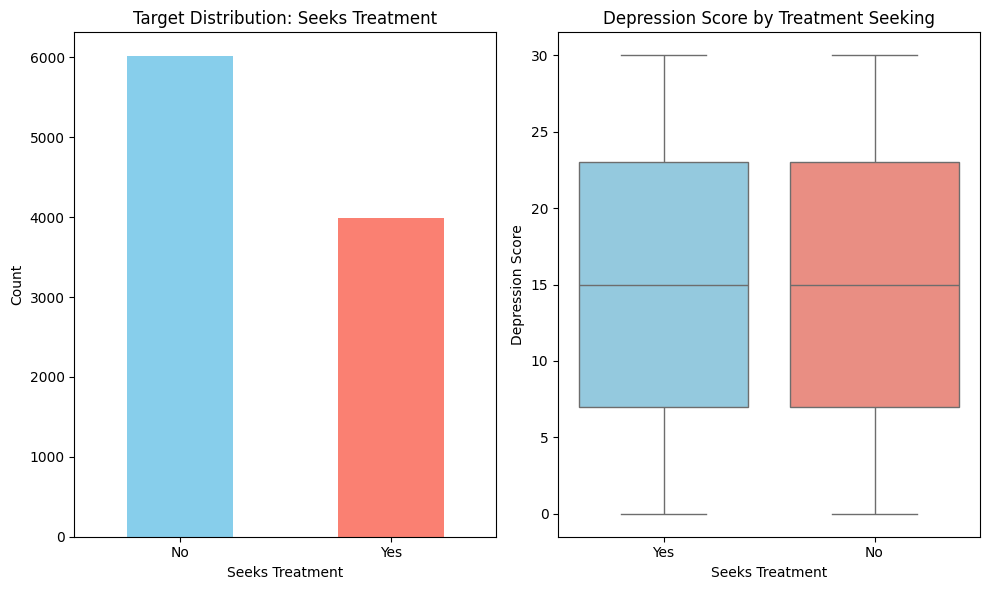

In [ ]:
# Visualization
# Distribution of target
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
df['seeks_treatment'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Distribution: Seeks Treatment')
plt.xlabel('Seeks Treatment')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Boxplot: Depression score by treatment
plt.subplot(1, 2, 2)
sns.boxplot(x='seeks_treatment', y='depression_score', data=df, palette=['skyblue', 'salmon'])
plt.title('Depression Score by Treatment Seeking')
plt.xlabel('Seeks Treatment')
plt.ylabel('Depression Score')

plt.tight_layout()
plt.savefig('target_analysis.png', dpi=300)
plt.show()

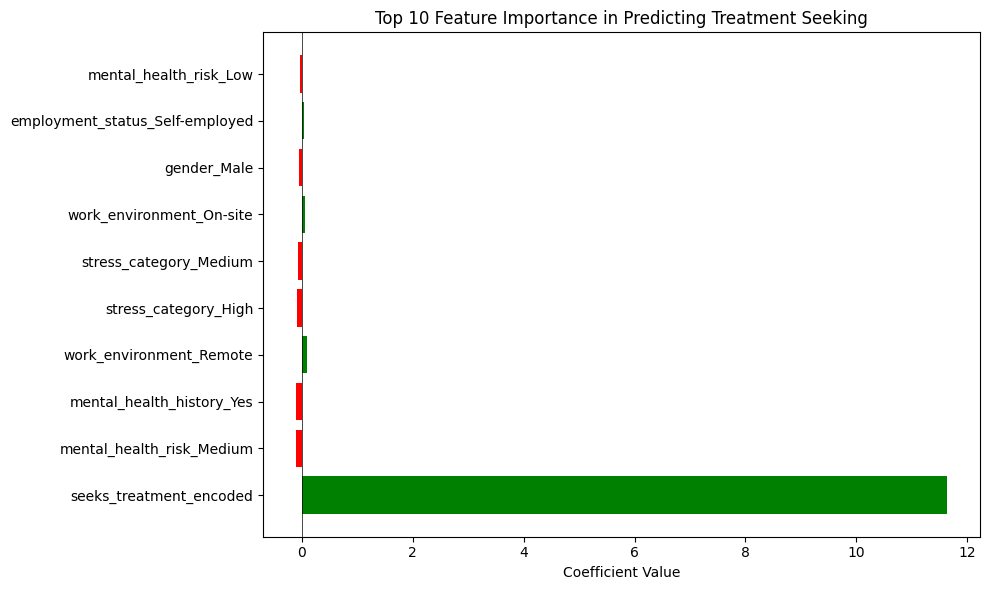

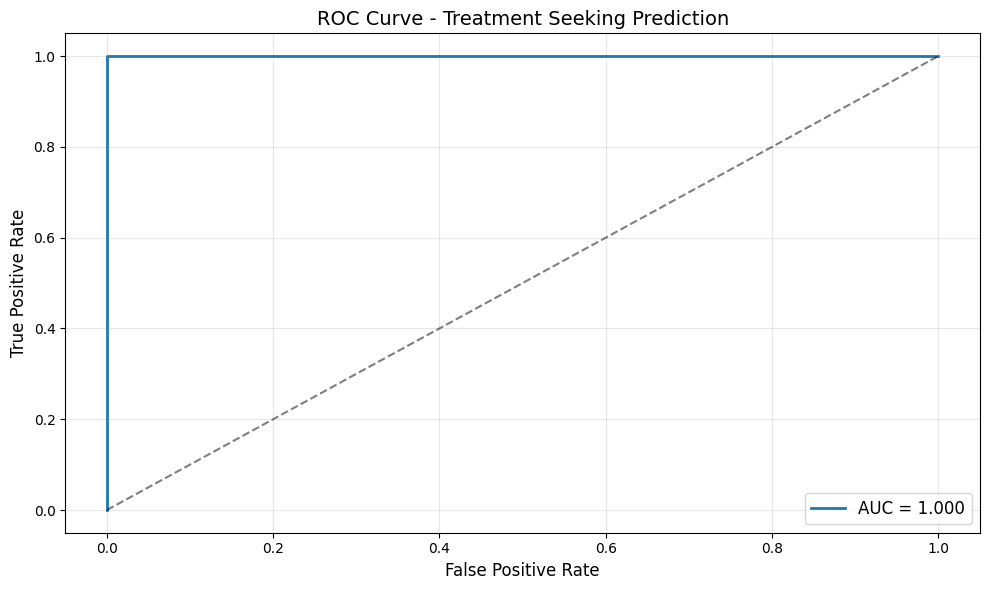

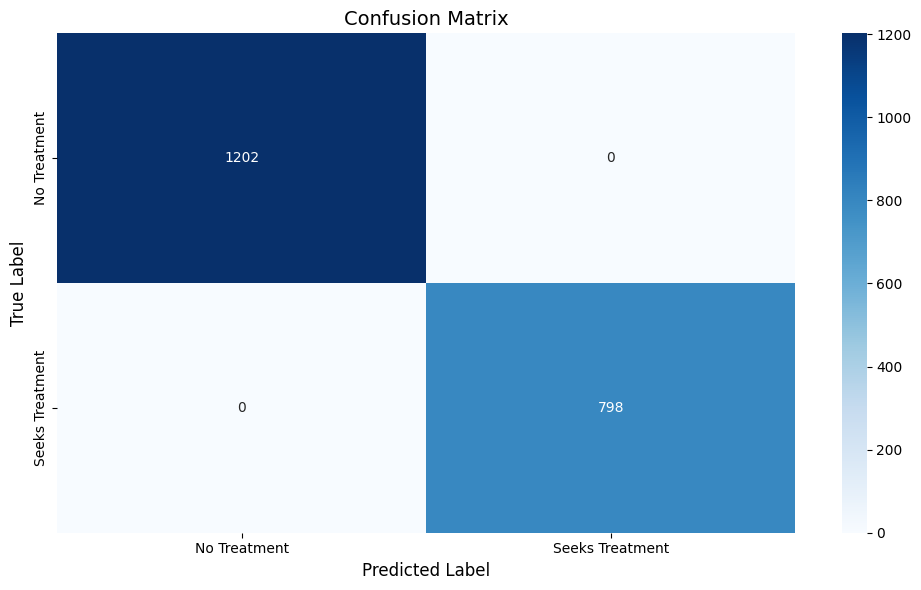

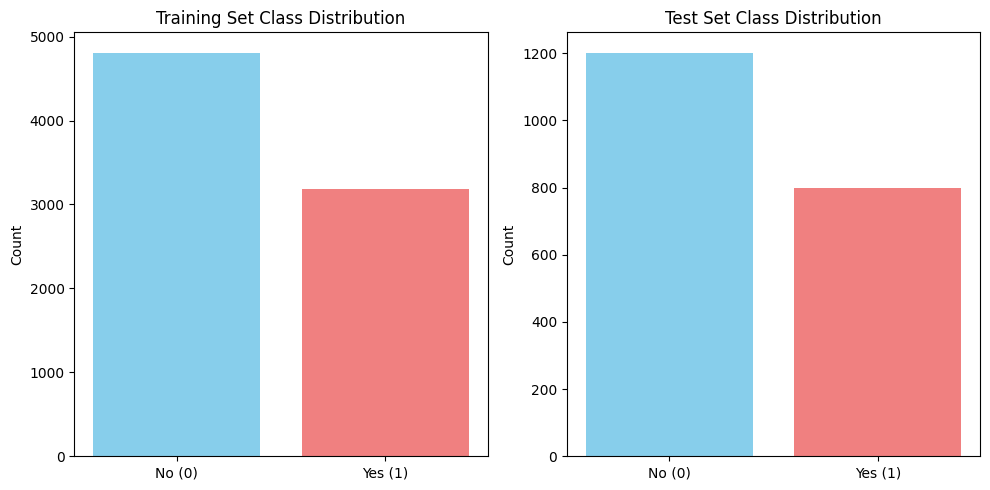

In [ ]:
#  Feature Importance Plot
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)
colors = ['red' if coef < 0 else 'green' for coef in top_10['Coefficient']]
plt.barh(range(len(top_10)), top_10['Coefficient'], color=colors)
plt.yticks(range(len(top_10)), top_10['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Importance in Predicting Treatment Seeking')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Treatment Seeking Prediction', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

#Confusion Matrix Heatmap
plt.figure(figsize=(10, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Treatment', 'Seeks Treatment'],
            yticklabels=['No Treatment', 'Seeks Treatment'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# Class Distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y_train_counts = pd.Series(y_train).value_counts()
plt.bar(['No (0)', 'Yes (1)'], y_train_counts.values, color=['skyblue', 'lightcoral'])
plt.title('Training Set Class Distribution')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
y_test_counts = pd.Series(y_test).value_counts()
plt.bar(['No (0)', 'Yes (1)'], y_test_counts.values, color=['skyblue', 'lightcoral'])
plt.title('Test Set Class Distribution')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()

## Correlation Matrix


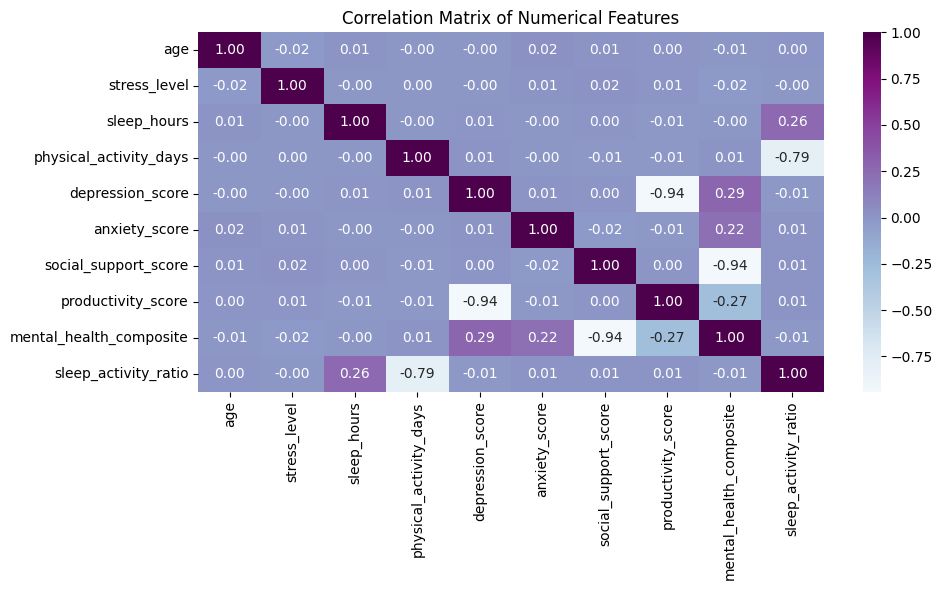

\nTop correlations with seeks_treatment:
seeks_treatment_encoded    1.000000
anxiety_score              0.010903
age                        0.009422
stress_level               0.008780
mental_health_composite    0.007774
physical_activity_days     0.006686
social_support_score       0.005215
depression_score           0.002473
sleep_activity_ratio       0.002184
sleep_hours                0.001853
Name: seeks_treatment_encoded, dtype: float64


In [52]:


# Select numerical columns for correlation
numerical_cols = ['age', 'stress_level', 'sleep_hours', 'physical_activity_days',
                  'depression_score', 'anxiety_score', 'social_support_score',
                  'productivity_score', 'mental_health_composite', 'sleep_activity_ratio']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='BuPu', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

# Identify top correlations with target
target_corr = df[numerical_cols + ['seeks_treatment_encoded']].corr()['seeks_treatment_encoded'].abs().sort_values(ascending=False)
print("\\nTop correlations with seeks_treatment:")
print(target_corr.head(10))

In [53]:
!git add .
!git commit -m "Completed Modelling"

[main bf65167] Completed Modelling
 5 files changed, 238 insertions(+), 275 deletions(-)
